Data collecting from three datasets

In [1]:
import pandas as pd

# Load multiple datasets
df1 = pd.read_csv('datasets/fake_job_postings.csv', low_memory=False)
df2 = pd.read_csv('datasets/Fake Postings.csv', low_memory=False)
df3 = pd.read_csv('datasets/job_train.csv', low_memory=False)
df4 = pd.read_csv('datasets/fake_job_postings1.csv', low_memory=False)
df5 = pd.read_csv('datasets/Fake_Jobs_Postings.csv', low_memory=False)
df6 = pd.read_csv('datasets/fake_job_postings2.csv', low_memory=False)
# Align column names -> Finding common columns
common_cols = list(set(df1.columns) & set(df2.columns) & set(df3.columns) & set(df4.columns) & set(df5.columns) & set(df6.columns))
df1, df2, df3, df4, df5, df6 = [df[common_cols] for df in [df1, df2, df3, df4, df5, df6]]

# Merge all datasets
df_combined = pd.concat([df1, df2, df3, df4, df5, df6], axis=0).drop_duplicates().reset_index(drop=True)

# Check merged shape and label balance
print("Total rows:", len(df_combined))
print(df_combined['fraudulent'].value_counts())


Total rows: 27457
fraudulent
0    16631
1    10826
Name: count, dtype: int64


In [2]:
import re  #regular expressions
import numpy as np

df = df_combined.copy()  #creating a working copy of combined dataset

# Normalize target labels
label_map = {
    'f': 0, 'F': 0, 'false': 0, 'False': 0, 'FALSE': 0, False: 0, 0: 0, '0': 0,
    't': 1, 'T': 1, 'true': 1, 'True': 1, 'TRUE': 1, True: 1, 1: 1, '1': 1
}
df['fraudulent'] = df['fraudulent'].map(label_map).astype('Int64')

#removing invalid labels
before = len(df)
df = df.dropna(subset=['fraudulent'])
df['fraudulent'] = df['fraudulent'].astype(int)
print(f"Dropped rows with invalid labels: {before - len(df)}")

#Handling remaining text columns
possible_cols = [
    'title','company_profile','description','requirements','benefits',
    'industry','employment_type','required_experience','required_education',
    'function','location','telecommuting','has_company_logo','has_questions'
]
existing = [c for c in possible_cols if c in df.columns]
missing = [c for c in possible_cols if c not in df.columns]
print("Using columns:", existing)
if missing:
    print("Missing columns (ok to miss):", missing)

#removing duplicates
dup_keys = [c for c in ['title','description'] if c in df.columns]
if dup_keys:
    before = len(df)
    df = df.drop_duplicates(subset=dup_keys)
    print(f"Removed potential duplicates based on {dup_keys}: {before - len(df)}")

#ensure text columns exists 
for c in ['title','company_profile','description','requirements','benefits','industry','employment_type','function','location']:
    if c not in df.columns:
        df[c] = ""

#fill missing columns
df[existing] = df[existing].fillna("")
#combining all text into one
df['text_raw'] = (
    df.get('title','') + " " + df.get('company_profile','') + " " + df.get('description','') + " " +
    df.get('requirements','') + " " + df.get('benefits','') + " " + df.get('industry','') + " " +
    df.get('employment_type','') + " " + df.get('function','') + " " + df.get('location','')
).astype(str)

# Text cleaning using regular expressions
_url = re.compile(r'(http[s]?://\S+|www\.\S+)')
_email = re.compile(r'\b[\w\.-]+@[\w\.-]+\.\w{2,}\b')
_nonalpha = re.compile(r'[^a-zA-Z\s]')
_multi_space = re.compile(r'\s+')

#data cleaning function
def clean_text(s: str) -> str:
    s = _url.sub(' ', s)
    s = _email.sub(' ', s)
    s = _nonalpha.sub(' ', s)
    s = s.lower()
    s = _multi_space.sub(' ', s).strip()
    return s

#apply cleaning
df['text'] = df['text_raw'].apply(clean_text)

before = len(df)
#removing very short text
df = df[df['text'].str.len() >= 20]
print(f"Dropped short/empty text rows: {before - len(df)}")

for bcol in ['telecommuting','has_company_logo','has_questions']:
    if bcol in df.columns:
        df[bcol] = df[bcol].replace({'t':1,'f':0,'True':1,'False':0, True:1, False:0}).fillna(0).astype(int)

counts = df['fraudulent'].value_counts()
perc = (counts / counts.sum() * 100).round(2)
print("\nClass distribution:")
print(counts)
print("\nClass %:")
print(perc)
print("\nSample lengths (chars) of text:", df['text'].str.len().describe())
#preview data
print("\nPreview:")
print(df[['fraudulent','title','location']].head(5))
#final dataset selection
keep_cols = ['text','fraudulent','title','location','employment_type','industry','has_company_logo','telecommuting','has_questions']
keep_cols = [c for c in keep_cols if c in df.columns]
df_clean = df[keep_cols].reset_index(drop=True)
print("\nFinal shape:", df_clean.shape)


Dropped rows with invalid labels: 0
Using columns: ['title', 'description', 'requirements', 'location']
Missing columns (ok to miss): ['company_profile', 'benefits', 'industry', 'employment_type', 'required_experience', 'required_education', 'function', 'telecommuting', 'has_company_logo', 'has_questions']
Removed potential duplicates based on ['title', 'description']: 1670
Dropped short/empty text rows: 1

Class distribution:
fraudulent
0    15113
1    10673
Name: count, dtype: int64

Class %:
fraudulent
0    58.61
1    41.39
Name: count, dtype: float64

Sample lengths (chars) of text: count    25786.000000
mean      1200.278678
std       1175.462659
min         23.000000
25%        175.000000
50%        894.000000
75%       1928.750000
max      14449.000000
Name: text, dtype: float64

Preview:
   fraudulent                                      title            location
0           0                           Marketing Intern    US, NY, New York
1           0  Customer Service - Cloud

🧾 Dataset Balance Summary
Total samples: 25786
Real (0): 15113
Fake (1): 10673
Fake %: 41.39%


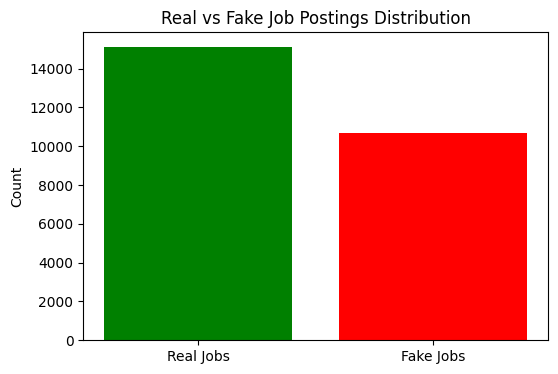

In [3]:
import matplotlib.pyplot as plt
#count real vs fake jobs
counts = df_clean['fraudulent'].value_counts()
#separate real and fake counts
real = counts[0]
fake = counts[1]

print("🧾 Dataset Balance Summary")
print(f"Total samples: {len(df_clean)}")
print(f"Real (0): {real}")
print(f"Fake (1): {fake}")
print(f"Fake %: {round(fake / len(df_clean) * 100, 2)}%")

plt.figure(figsize=(6,4)) #create a bar chart
plt.bar(['Real Jobs', 'Fake Jobs'], [real, fake], color=['green', 'red'])
plt.title('Real vs Fake Job Postings Distribution')
plt.ylabel('Count')
plt.show()


In [4]:
from sklearn.utils import resample  #resampling from scikit-learn -> used for randomly selecting rows

#fit real and fake jobs
df_real = df_clean[df_clean['fraudulent'] == 0]
df_fake = df_clean[df_clean['fraudulent'] == 1]

#oversample the minority class
df_fake_up = resample(df_fake, replace=True, n_samples=len(df_real), random_state=42)
df_balanced = pd.concat([df_real, df_fake_up]).sample(frac=1, random_state=42).reset_index(drop=True)
#combine dataset
print("✅ Balanced dataset created")
print(df_balanced['fraudulent'].value_counts())
print(df_balanced['fraudulent'].value_counts(normalize=True) * 100)
print("Total samples:", len(df_balanced))


✅ Balanced dataset created
fraudulent
1    15113
0    15113
Name: count, dtype: int64
fraudulent
1    50.0
0    50.0
Name: proportion, dtype: float64
Total samples: 30226


d:\26_P2_fake_job_prediction_backend\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



📊 Model Evaluation Report (After Enrichment):
              precision    recall  f1-score   support

           0      0.968     1.000     0.983      3023
           1      1.000     0.967     0.983      3023

    accuracy                          0.983      6046
   macro avg      0.984     0.983     0.983      6046
weighted avg      0.984     0.983     0.983      6046

✅ Accuracy: 0.9831


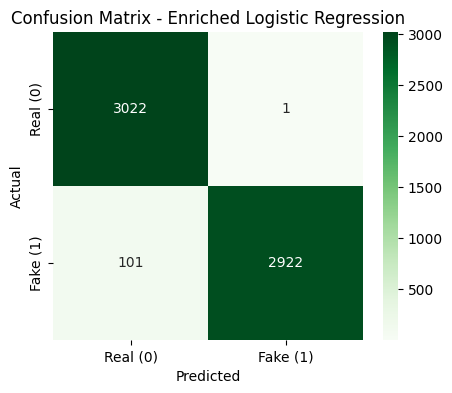

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
from scipy.sparse import hstack

# Suspicious keywords
suspicious_keywords = [
    'earn','money','income','cash','hurry','limited','urgent','apply now','no experience',
    'work from home','easy job','quick money','investment','bitcoin','crypto','telegram',
    'whatsapp','pay to apply','registration fee','send details','bank account','click here','link'
]

def suspicious_feature(text):
    text = text.lower()
    return sum(word in text for word in suspicious_keywords) #count how many suspicious phrases appear

#features are created
df_balanced['text_len'] = df_balanced['text'].apply(len)
df_balanced['num_suspicious'] = df_balanced['text'].apply(suspicious_feature) # number or scam-style keywords
df_balanced['text_len'] = np.log1p(df_balanced['text_len']) #reduces effect of very large values

#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['text'], df_balanced['fraudulent'],
    test_size=0.2, random_state=42, stratify=df_balanced['fraudulent']
)

#TF-IDF vectorisation
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2))
#transform text into numbers
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#add extra numeric features
train_extra = df_balanced.loc[X_train.index, ['text_len','num_suspicious']].to_numpy()
test_extra = df_balanced.loc[X_test.index, ['text_len','num_suspicious']].to_numpy()

#combine all features
X_train_final = hstack([X_train_tfidf, train_extra])
X_test_final = hstack([X_test_tfidf, test_extra])

#Logistic regression model
model_enriched = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
#train the model
model_enriched.fit(X_train_final, y_train)

y_pred = model_enriched.predict(X_test_final) #prediction

#model evaluation
print("\n📊 Model Evaluation Report (After Enrichment):")
print(classification_report(y_test, y_pred, digits=3))
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred):.4f}")

#confusion matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real (0)','Fake (1)'], yticklabels=['Real (0)','Fake (1)'])
plt.title('Confusion Matrix - Enriched Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [7]:
# === Cell 7: Test the enriched model on real/fake examples ===
#this function accepts raw job description and returns prediction+confidence
def predict_job_posting_enriched(text):
    import numpy as np
    
    # Clean input
    text_clean = " ".join(text.lower().split())

    # TF-IDF transform
    X_input_tfidf = vectorizer.transform([text_clean])
    
    # Extra features
    text_len = np.log1p(len(text_clean))
    num_suspicious = sum(word in text_clean for word in [
        'earn', 'money', 'income', 'cash', 'hurry', 'limited', 'urgent',
        'apply now', 'no experience', 'work from home', 'easy job', 'quick money',
        'investment', 'bitcoin', 'crypto', 'telegram', 'whatsapp', 'pay to apply',
        'registration fee', 'send details', 'bank account', 'click here', 'link'
    ])
    
    #create numeric feature array
    X_extra = np.array([[text_len, num_suspicious]])
    
    # Combine TF-IDF + numeric features
    from scipy.sparse import hstack
    X_input_final = hstack([X_input_tfidf, X_extra])
    
    # Predict
    pred = model_enriched.predict(X_input_final)[0]
    proba = model_enriched.predict_proba(X_input_final)[0]
    
    #human-readable output
    label = "🟥 FAKE JOB POSTING" if pred == 1 else "🟩 REAL JOB POSTING"
    confidence = round(float(np.max(proba)) * 100, 2)
    
    print(f"\nPrediction: {label}")
    print(f"Confidence: {confidence}%")
    print(f"→ Real (0): {proba[0]:.4f} | Fake (1): {proba[1]:.4f}")
    print("-" * 50)

# 🔹 Example 1: Real job
text_real = """
We are looking for a Data Analyst to join our growing analytics team in Hyderabad.
Candidates should have strong SQL, Excel, and Python skills.
Competitive salary, health insurance, and hybrid work options provided.
"""
predict_job_posting_enriched(text_real)

# 🔹 Example 2: Fake job
text_fake = """
Earn $5000 per week easily by working from home! No experience required.
Just send your personal details and start earning immediately. Limited seats!
"""
predict_job_posting_enriched(text_fake)

# 🔹 Example 3: Another fake posting
text_fake2 = """
Work from home online typing job. Pay to register and start earning daily.
Send your bank account details and we will activate your account instantly.
"""
predict_job_posting_enriched(text_fake2)



Prediction: 🟩 REAL JOB POSTING
Confidence: 95.63%
→ Real (0): 0.9563 | Fake (1): 0.0437
--------------------------------------------------

Prediction: 🟥 FAKE JOB POSTING
Confidence: 81.23%
→ Real (0): 0.1877 | Fake (1): 0.8123
--------------------------------------------------

Prediction: 🟥 FAKE JOB POSTING
Confidence: 70.03%
→ Real (0): 0.2997 | Fake (1): 0.7003
--------------------------------------------------


In [8]:
# === Cell 8: Test job posting mentioning Gmail contact ===

# Example 1: Legit job with a company domain email (real)
text_real_email = """
We are hiring a Machine Learning Engineer for our Hyderabad office.
Experience in TensorFlow, Python, and NLP preferred.
Send your CV to careers@techfusion.ai with the subject line 'ML Engineer Application'.
"""
predict_job_posting_enriched(text_real_email)

# Example 2: Suspicious job asking to contact a Gmail (fake)
text_fake_email = """
Work from home data entry job! Earn up to $4000 monthly.
No experience needed. Just send your resume to jobsfree2024@gmail.com to get started.
Limited openings available!
"""
predict_job_posting_enriched(text_fake_email)

# Example 3: Another tricky one (semi-fake)
text_fake2_email = """
We are urgently hiring for a remote marketing assistant.
Apply now by sending your details to marketingrecruiters@gmail.com.
No previous experience required, full training provided.
"""
predict_job_posting_enriched(text_fake2_email)



Prediction: 🟩 REAL JOB POSTING
Confidence: 70.47%
→ Real (0): 0.7047 | Fake (1): 0.2953
--------------------------------------------------

Prediction: 🟥 FAKE JOB POSTING
Confidence: 92.28%
→ Real (0): 0.0772 | Fake (1): 0.9228
--------------------------------------------------

Prediction: 🟥 FAKE JOB POSTING
Confidence: 51.49%
→ Real (0): 0.4851 | Fake (1): 0.5149
--------------------------------------------------


In [ ]:
# === Cell 9: Save Logistic Regression Model and Vectorizer ===
import joblib   #for saving trained model
import os

# Create a folder to store artifacts
os.makedirs("saved_models", exist_ok=True)

# Save model and vectorizer
joblib.dump(model_enriched, "saved_models/fake_job_detector_model_logestic.pkl")
joblib.dump(vectorizer, "saved_models/tfidf_vectorizer_logestic.pkl")

print("✅ Model and vectorizer saved successfully!")

# Confirm files
print("\nSaved files:")
for f in os.listdir("saved_models"):    
    print("📁", f)


✅ Model and vectorizer saved successfully!

Saved files:
📁 fake_job_detector_model_logestic.pkl
📁 tfidf_vectorizer_logestic.pkl


In [10]:
import numpy as np #numeric operations
from scipy.sparse import hstack #merge features
import re
import joblib  #load saved ML artifacts

# Load model + vectorizer
model_loaded = joblib.load("saved_models/fake_job_detector_model_logestic.pkl")
vectorizer_loaded = joblib.load("saved_models/tfidf_vectorizer_logestic.pkl")

# Suspicious keywords list (same as training)
suspicious_keywords = [
    'earn', 'money', 'income', 'cash', 'hurry', 'limited', 'urgent',
    'apply now', 'no experience', 'work from home', 'easy job', 'quick money',
    'investment', 'bitcoin', 'crypto', 'telegram', 'whatsapp', 'pay to apply',
    'registration fee', 'send details', 'bank account', 'click here', 'link'
]

#prediction function
def predict_job_posting_loaded(text):
    """Predict using the saved logistic model with numeric features."""
    text_clean = re.sub(r'\s+', ' ', text.lower().strip())
    
    # TF-IDF transformation
    X_tfidf = vectorizer_loaded.transform([text_clean])
    
    # Create the 2 additional numeric features
    text_len = np.log1p(len(text_clean))
    num_suspicious = sum(word in text_clean for word in suspicious_keywords)
    X_extra = np.array([[text_len, num_suspicious]])
    
    # Combine both
    X_final = hstack([X_tfidf, X_extra])
    
    # Predict
    pred = model_loaded.predict(X_final)[0]
    proba = model_loaded.predict_proba(X_final)[0]
    
    label = "🟥 FAKE JOB POSTING" if pred == 1 else "🟩 REAL JOB POSTING"
    print(f"\nPrediction: {label}")
    print(f"→ Real (0): {proba[0]:.4f} | Fake (1): {proba[1]:.4f}")
    print(f"Confidence: {round(np.max(proba)*100, 2)}%")

# Example test
text = "Work from home, earn $3000 weekly without experience. Send your details now!"
predict_job_posting_loaded(text)



Prediction: 🟥 FAKE JOB POSTING
→ Real (0): 0.1562 | Fake (1): 0.8438
Confidence: 84.38%


# Explanation :

Brief about Training FLow

| Step | Process                  | Description                      | Output            |
| ---- | ------------------------ | -------------------------------- | ----------------- |
| 1    | Data Loading             | Merge & unify 6 Kaggle datasets  | `df_combined`     |
| 2    | Label & Text Cleaning    | Normalize labels, clean text     | `df` (clean)      |
| 3    | Feature Prep & Balancing | Handle imbalance, visualize data | `df_balanced`     |
| 4    | Vectorization & Training | TF-IDF + Logistic Regression     | Trained Model     |
| 5    | Prediction               | Test on real/fake job posts      | Real-time results |


🧩 Cell 1 — Step 1: Data Loading & Merging
🎯 Goal:

Combine multiple fake job posting datasets from Kaggle into a single clean dataset.

🧠 What Happens Here:

Load 6 different Kaggle CSV datasets using pandas.

Identify common columns shared among all datasets to maintain consistency.

Concatenate them vertically using pd.concat() to form a unified dataset.

Remove duplicate rows and reset the index for a clean structure.

Display:

Total number of merged rows.

Count of real vs. fake jobs.

-------------------------------------------------------------------------------------------------------------

Cell 2 — Step 2: Label Normalization & Text Preparation
🎯 Goal:

Clean target labels and prepare raw text data for NLP processing.

🧠 What Happens Here:

Convert different label forms (True, false, t, 1, etc.) into standardized integers (0 = Real, 1 = Fake).

Drop rows with missing or invalid labels.

Keep only relevant columns like:

title, company_profile, description, requirements, benefits, etc.

Remove duplicates based on title and description.

Combine multiple text columns into a single field called text_raw.

🧽 Text Cleaning Includes:

Removing:

URLs, emails, special characters, numbers.

Converting to lowercase.

Removing extra spaces.

-----------------------------------------------------------------------------------------
🔧 Cell 3 — Step 3: Feature Engineering & Data Preparation
🎯 Goal:

Prepare structured features and handle class imbalance for modeling.

🧠 What Happens Here:

Convert binary-like columns (telecommuting, has_company_logo, has_questions) into integer form (0 or 1).

Display:

Class distribution (real vs fake %).

Text length statistics.

Visualize dataset balance using a bar chart (Real vs Fake).

⚖️ Balancing:

Detects imbalance (usually more real jobs).

Upsamples fake job postings using sklearn.utils.resample to create a balanced dataset with equal class representation.

------------------------------------------------------------------------------------------------------
🧮 Cell 4 — Step 4: Text Vectorization & Model Training
🎯 Goal:

Convert text data to numerical format and train the prediction model.

🧠 What Happens Here:

Feature Engineering:

Add two numerical features:

text_len → log of text length.

num_suspicious → number of scam-like keywords (e.g., “earn”, “money”, “urgent”).

Split dataset into Train (80%) and Test (20%).

Use TF-IDF Vectorizer:

Remove English stopwords.

Use both unigrams and bigrams (1–2 word combinations).

Max features = 10,000.

Combine TF-IDF vectors with numeric features using hstack().

🤖 Model Training:

Use Logistic Regression with:

class_weight='balanced'

max_iter=1000

Train the model on the enriched feature set.

----------------------------------------------------------------------------------------------------------------

🧠 Cell 5 — Step 5: Real-Time Prediction Function & Testing
🎯 Goal:

Test model predictions on real job examples and fake job scams.

🧠 What Happens Here:

Define a function predict_job_posting_enriched(text) that:

Cleans the input text.

Converts it into TF-IDF + numeric feature form.

Predicts label (0 = Real, 1 = Fake).

Displays confidence score and probability breakdown.

🧪 Testing:

Run 3 example predictions:

Real Job Post — genuine company job description.

Fake Job Post 1 — contains scam keywords like “earn $5000”, “send details”.

Fake Job Post 2 — “Pay to register”, “bank account details”.



# Model Comparison: Logistic Regression vs XGBoost

In [11]:
# =========================================
# 🧠 Fake Job Prediction — Model Comparison
# Logistic Regression vs XGBoost
# =========================================

import numpy as np
from sklearn.model_selection import train_test_split  #->splits data into training and testing sets
from sklearn.feature_extraction.text import TfidfVectorizer  #text-numeric features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score #model performance
from scipy.sparse import hstack  #combining text features+numeric features
from xgboost import XGBClassifier #model-> tree-based
import seaborn as sns #for visualisation
import matplotlib.pyplot as plt

# -------------------------------
# 🔹 Step 1: Feature Preparation
# -------------------------------

# Suspicious keywords list
suspicious_keywords = [
    'earn','money','income','cash','hurry','limited','urgent','apply now','no experience',
    'work from home','easy job','quick money','investment','bitcoin','crypto','telegram',
    'whatsapp','pay to apply','registration fee','send details','bank account','click here','link'
]

# Count suspicious words
def suspicious_feature(text):
    text = text.lower()
    return sum(word in text for word in suspicious_keywords)

# Create extra numeric features
df_balanced['text_len'] = np.log1p(df_balanced['text'].apply(len))
df_balanced['num_suspicious'] = df_balanced['text'].apply(suspicious_feature)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['text'], df_balanced['fraudulent'],
    test_size=0.2, random_state=42, stratify=df_balanced['fraudulent']
)

# TF-IDF vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Combine TF-IDF + numeric features
train_extra = df_balanced.loc[X_train.index, ['text_len','num_suspicious']].to_numpy()
test_extra = df_balanced.loc[X_test.index, ['text_len','num_suspicious']].to_numpy()

X_train_final = hstack([X_train_tfidf, train_extra])
X_test_final = hstack([X_test_tfidf, test_extra])

print("✅ Feature preparation completed")
print("Train shape:", X_train_final.shape, "| Test shape:", X_test_final.shape)


✅ Feature preparation completed
Train shape: (24180, 10002) | Test shape: (6046, 10002)



🚀 Training Logistic Regression


d:\26_P2_fake_job_prediction_backend\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


✅ Logistic Regression Accuracy: 0.9831, F1: 0.9828

Classification Report (Logistic Regression):
               precision    recall  f1-score   support

           0      0.968     1.000     0.983      3023
           1      1.000     0.967     0.983      3023

    accuracy                          0.983      6046
   macro avg      0.984     0.983     0.983      6046
weighted avg      0.984     0.983     0.983      6046



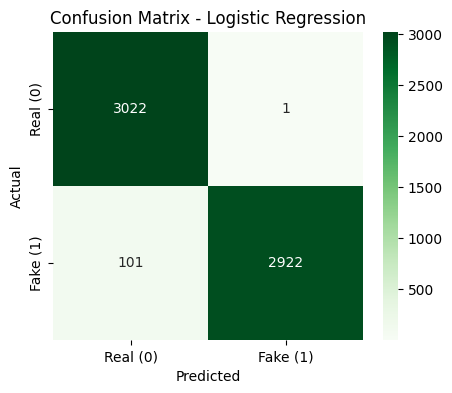

In [12]:

# ---------------------------------
# 🔹 Step 2: Logistic Regression
# ---------------------------------
print("\n==============================")
print("🚀 Training Logistic Regression")
print("==============================")

#creating Logistic regression model 
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
#training the model
model_lr.fit(X_train_final, y_train)
#making predictions
y_pred_lr = model_lr.predict(X_test_final)

#accuracy score
lr_acc = accuracy_score(y_test, y_pred_lr)
#F1 score
lr_f1 = f1_score(y_test, y_pred_lr)
print(f"✅ Logistic Regression Accuracy: {lr_acc:.4f}, F1: {lr_f1:.4f}")
print("\nClassification Report (Logistic Regression):\n", classification_report(y_test, y_pred_lr, digits=3))

# Confusion matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=['Real (0)','Fake (1)'], yticklabels=['Real (0)','Fake (1)'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



🚀 Training XGBoost Classifier


d:\26_P2_fake_job_prediction_backend\myenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:15:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost Accuracy: 0.9931, F1: 0.9930

Classification Report (XGBoost):
               precision    recall  f1-score   support

           0      0.989     0.998     0.993      3023
           1      0.998     0.988     0.993      3023

    accuracy                          0.993      6046
   macro avg      0.993     0.993     0.993      6046
weighted avg      0.993     0.993     0.993      6046



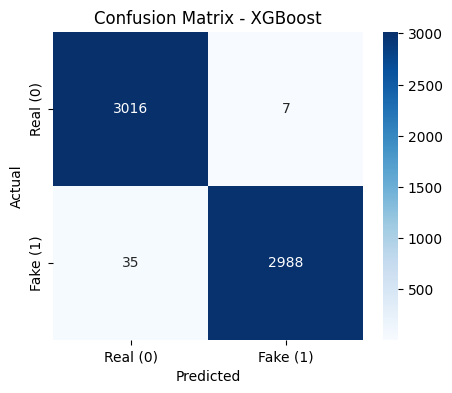

In [13]:

# --------------------------
# 🔹 Step 3: XGBoost Model -> tree based, very strong complex data handling
# --------------------------
print("\n==============================")
print("🚀 Training XGBoost Classifier")
print("==============================")

#creating XGBoost model
model_xgb = XGBClassifier(
    n_estimators=300, #number of decision trees-> more tress-> better learning
    learning_rate=0.1,  #prevents overfitting
    max_depth=6, #max depth of tree
    subsample=0.8, #each tree sees only 80% of data
    colsample_bytree=0.8, #each tree uses 80% of features
    eval_metric='logloss', #measures classification errors
    use_label_encoder=False, #required for newer XGBoost version
    random_state=42 #ensure reproducibility
)

#training XGBoost model
model_xgb.fit(X_train_final, y_train)
#making predictions
y_pred_xgb = model_xgb.predict(X_test_final)

#accuracy score
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
print(f"✅ XGBoost Accuracy: {xgb_acc:.4f}, F1: {xgb_f1:.4f}")
print("\nClassification Report (XGBoost):\n", classification_report(y_test, y_pred_xgb, digits=3))

# Confusion matrix - XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Real (0)','Fake (1)'], yticklabels=['Real (0)','Fake (1)'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()




📊 Model Performance Comparison:
                 Model  Accuracy  F1 Score
0  Logistic Regression    0.9831    0.9828
1              XGBoost    0.9931    0.9930


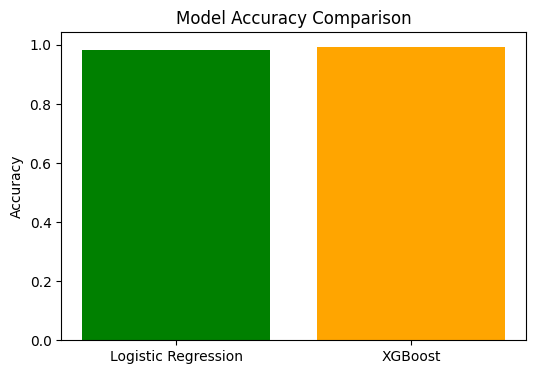

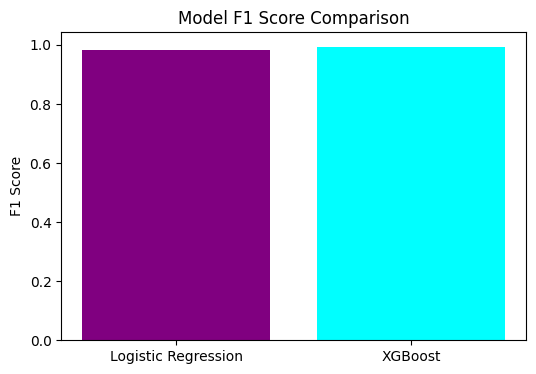

In [14]:

# -------------------------------
# 🔹 Step 4: Model Comparison
# -------------------------------
print("\n📊 Model Performance Comparison:")
print("="*35)
comparison = {
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy': [round(lr_acc, 4), round(xgb_acc, 4)],
    'F1 Score': [round(lr_f1, 4), round(xgb_f1, 4)]
}

import pandas as pd
comp_df = pd.DataFrame(comparison)
print(comp_df)

plt.figure(figsize=(6,4))
plt.bar(comp_df['Model'], comp_df['Accuracy'], color=['green','orange'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

plt.figure(figsize=(6,4))
plt.bar(comp_df['Model'], comp_df['F1 Score'], color=['purple','cyan'])
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.show()

In [15]:
# =========================================
# 🧪 Step 5 — Testing on Real & Fake Examples
# =========================================

def predict_with_models(text):
    """
    Predicts if a given job posting is real or fake using
    both Logistic Regression and XGBoost models.
    """
    text_clean = " ".join(text.lower().split())
    X_tfidf = vectorizer.transform([text_clean])
    text_len = np.log1p(len(text_clean))
    num_suspicious = sum(word in text_clean for word in suspicious_keywords)
    X_extra = np.array([[text_len, num_suspicious]])
    
    from scipy.sparse import hstack
    X_input_final = hstack([X_tfidf, X_extra])
    
    # Logistic Regression prediction
    pred_lr = model_lr.predict(X_input_final)[0]
    proba_lr = model_lr.predict_proba(X_input_final)[0]
    
    # XGBoost prediction
    pred_xgb = model_xgb.predict(X_input_final)[0]
    proba_xgb = model_xgb.predict_proba(X_input_final)[0]
    
    print("🧾 Input Text:")
    print(text.strip())
    print("-" * 60)
    print(f"🟩 Logistic Regression → {'FAKE' if pred_lr==1 else 'REAL'}  |  Confidence: {round(max(proba_lr)*100,2)}%")
    print(f"🟦 XGBoost              → {'FAKE' if pred_xgb==1 else 'REAL'}  |  Confidence: {round(max(proba_xgb)*100,2)}%")
    print("=" * 60 + "\n")

# ------------------------------------
# 🔹 5 Sample Job Postings for Testing
# ------------------------------------

test_samples = [
    # ✅ Real Jobs
    """We are hiring a Software Engineer in Bangalore.
       Candidates should have strong knowledge of Python, REST APIs, and SQL.
       Competitive pay, work-from-home flexibility, and career growth opportunities.""",
    
    """Join our marketing team as a Digital Marketing Executive.
       Must be familiar with SEO, Google Ads, and social media campaigns.
       Attractive package and performance bonuses.""",
    
    """Looking for a Data Analyst at our Hyderabad office.
       Must know Power BI, Excel, and SQL. Great culture and learning environment.""",
    
    # 🚫 Fake Jobs
    """Earn $4000 weekly by working from home! No experience required.
       Send your personal details and bank info to get started today. Limited openings!""",
    
    """Online data entry jobs available. Pay small registration fee and start earning instantly.
       Contact on WhatsApp for more details. Hurry!"""
]

# Run predictions on all samples
for idx, text in enumerate(test_samples, 1):
    print(f"🧪 Sample {idx}")
    predict_with_models(text)


🧪 Sample 1
🧾 Input Text:
We are hiring a Software Engineer in Bangalore.
       Candidates should have strong knowledge of Python, REST APIs, and SQL.
       Competitive pay, work-from-home flexibility, and career growth opportunities.
------------------------------------------------------------
🟩 Logistic Regression → REAL  |  Confidence: 87.1%
🟦 XGBoost              → REAL  |  Confidence: 85.12000274658203%

🧪 Sample 2
🧾 Input Text:
Join our marketing team as a Digital Marketing Executive.
       Must be familiar with SEO, Google Ads, and social media campaigns.
       Attractive package and performance bonuses.
------------------------------------------------------------
🟩 Logistic Regression → REAL  |  Confidence: 95.82%
🟦 XGBoost              → REAL  |  Confidence: 99.47000122070312%

🧪 Sample 3
🧾 Input Text:
Looking for a Data Analyst at our Hyderabad office.
       Must know Power BI, Excel, and SQL. Great culture and learning environment.
---------------------------------------

In [16]:
# =========================================
# 💾 Step 6 — Save XGBoost Model for Inference
# =========================================

import joblib
import os

# Create a directory to save models
os.makedirs("models", exist_ok=True)

# Save XGBoost model
xgb_model_path = "models/xgboost_fakejob_model.pkl"
joblib.dump(model_xgb, xgb_model_path)

# Save TF-IDF vectorizer
vectorizer_path = "models/tfidf_vectorizer.pkl"
joblib.dump(vectorizer, vectorizer_path)

# Save suspicious keywords list (optional)
keywords_path = "models/suspicious_keywords.pkl"
joblib.dump(suspicious_keywords, keywords_path)

print("✅ Model and vectorizer successfully saved!")
print(f"📂 XGBoost model path: {xgb_model_path}")
print(f"📂 Vectorizer path: {vectorizer_path}")


✅ Model and vectorizer successfully saved!
📂 XGBoost model path: models/xgboost_fakejob_model.pkl
📂 Vectorizer path: models/tfidf_vectorizer.pkl


In [17]:
# =========================================
# 🔁 Step 7 — Load Saved Model for Inference
# =========================================

import joblib
from scipy.sparse import hstack
import numpy as np

# Load saved files
model_xgb_loaded = joblib.load("models/xgboost_fakejob_model.pkl")
vectorizer_loaded = joblib.load("models/tfidf_vectorizer.pkl")
suspicious_keywords_loaded = joblib.load("models/suspicious_keywords.pkl")

print("✅ XGBoost model and vectorizer loaded successfully!")

# ---------------------------
# 🔹 Define Inference Function
# ---------------------------

def predict_fake_job_xgb(text):
    text_clean = " ".join(text.lower().split())
    
    # Transform using loaded vectorizer
    X_tfidf = vectorizer_loaded.transform([text_clean])
    
    # Compute numeric features
    text_len = np.log1p(len(text_clean))
    num_suspicious = sum(word in text_clean for word in suspicious_keywords_loaded)
    X_extra = np.array([[text_len, num_suspicious]])
    
    # Combine TF-IDF + numeric
    X_input_final = hstack([X_tfidf, X_extra])
    
    # Predict
    pred = model_xgb_loaded.predict(X_input_final)[0]
    proba = model_xgb_loaded.predict_proba(X_input_final)[0]
    
    label = "🟥 FAKE JOB POSTING" if pred == 1 else "🟩 REAL JOB POSTING"
    confidence = round(float(np.max(proba)) * 100, 2)
    
    print(f"\nPrediction: {label}")
    print(f"Confidence: {confidence}%")
    print(f"→ Real (0): {proba[0]:.4f} | Fake (1): {proba[1]:.4f}")
    print("-" * 50)

# ---------------------------
# 🧪 Test Loaded Model
# ---------------------------

sample_text = """Earn $4000 weekly by working from home! No experience required. Send your details now!"""
predict_fake_job_xgb(sample_text)


✅ XGBoost model and vectorizer loaded successfully!

Prediction: 🟥 FAKE JOB POSTING
Confidence: 95.52%
→ Real (0): 0.0448 | Fake (1): 0.9552
--------------------------------------------------


# Training a BERT-based model

In [ ]:
# ============================================================
# 🧠 Fake Job Prediction — BERT Fine-tuning + Comparison
# ============================================================

# --- 1️⃣ Install Correct Dependencies ---
#pip install -q protobuf==3.20.3 transformers==4.39.3 torch torchvision torchaudio datasets==2.19.0

# --- 2️⃣ Imports ---
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
from tqdm.auto import tqdm

# --- 3️⃣ Dataset Preparation ---
texts = df_balanced['text'].tolist()
labels = df_balanced['fraudulent'].tolist()

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class JobDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = JobDataset(X_train_txt, y_train, tokenizer)
test_dataset  = JobDataset(X_test_txt, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

# --- 4️⃣ Model Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, correct_bias=False)
epochs = 3
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)
loss_fn = torch.nn.CrossEntropyLoss().to(device)

# --- 5️⃣ Training Loop ---
for epoch in range(epochs):
    print(f"\n🚀 Epoch {epoch+1}/{epochs}")
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Average training loss: {avg_train_loss:.4f}")

# --- 6️⃣ Evaluation ---
model.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

bert_acc = accuracy_score(y_true, y_pred)
bert_f1 = f1_score(y_true, y_pred)
print("\n📊 BERT Performance Report:")
print(f"✅ Accuracy: {bert_acc:.4f}")
print(f"✅ F1 Score: {bert_f1:.4f}")
print(classification_report(y_true, y_pred, digits=3))

# --- 7️⃣ Compare with XGBoost ---
print("\n📋 Model Comparison Summary")
comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'BERT'],
    'Accuracy': [xgb_acc, bert_acc],
    'F1 Score': [xgb_f1, bert_f1]
})
print(comparison_df)

# --- 8️⃣ Visualization ---
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['orange','blue'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

plt.figure(figsize=(6,4))
plt.bar(comparison_df['Model'], comparison_df['F1 Score'], color=['orange','blue'])
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.show()


✅ Using device: cpu


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
# ============================================================
# 🧪 Step 9 — Testing BERT Model on Real & Fake Job Samples
# ============================================================

def predict_with_bert(text, model, tokenizer, max_len=128):
    """
    Predict whether a job posting is real or fake using fine-tuned BERT.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Tokenize input text
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits
        probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()[0]
        pred = np.argmax(probs)

    label = "🟥 FAKE JOB POSTING" if pred == 1 else "🟩 REAL JOB POSTING"
    confidence = round(float(np.max(probs)) * 100, 2)

    print("🧾 Input Text:")
    print(text.strip())
    print("-" * 60)
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence}%")
    print(f"→ Real (0): {probs[0]:.4f} | Fake (1): {probs[1]:.4f}")
    print("=" * 60 + "\n")


# 🔹 5 Example Job Posts
test_samples = [
    # ✅ Real Job Examples
    """We are looking for a Software Engineer to join our team in Hyderabad.
       The candidate should be proficient in Python, APIs, and SQL.
       Competitive salary and benefits included.""",

    """Join our HR department as a Talent Acquisition Executive.
       You must have good communication skills and prior experience in recruitment.""",

    """We are hiring a Data Analyst for our Pune office.
       Strong knowledge of Excel, Power BI, and data visualization is required.""",

    # 🚫 Fake Job Examples
    """Earn $5000 per week easily from home! No experience required.
       Send your personal details and bank account number to get started immediately!""",

    """Online typing jobs available! Pay a small registration fee and start earning today.
       Contact us on WhatsApp to apply. Limited openings!"""
]

# 🔹 Run Predictions
for i, sample in enumerate(test_samples, 1):
    print(f"🧪 Sample {i}")
    predict_with_bert(sample, model, tokenizer)


🧪 Sample 1
🧾 Input Text:
We are looking for a Software Engineer to join our team in Hyderabad.
       The candidate should be proficient in Python, APIs, and SQL.
       Competitive salary and benefits included.
------------------------------------------------------------
Prediction: 🟩 REAL JOB POSTING
Confidence: 99.17%
→ Real (0): 0.9917 | Fake (1): 0.0083

🧪 Sample 2
🧾 Input Text:
Join our HR department as a Talent Acquisition Executive.
       You must have good communication skills and prior experience in recruitment.
------------------------------------------------------------
Prediction: 🟩 REAL JOB POSTING
Confidence: 97.05%
→ Real (0): 0.9705 | Fake (1): 0.0295

🧪 Sample 3
🧾 Input Text:
We are hiring a Data Analyst for our Pune office.
       Strong knowledge of Excel, Power BI, and data visualization is required.
------------------------------------------------------------
Prediction: 🟩 REAL JOB POSTING
Confidence: 99.05%
→ Real (0): 0.9905 | Fake (1): 0.0095

🧪 Sample 4
🧾 Inp

In [14]:
# ============================================================
# 🧠 Step 10 — Compare XGBoost vs BERT on Same Job Samples
# ============================================================

def compare_models_on_text(text, vectorizer, model_xgb, model_bert, tokenizer, suspicious_keywords):
    """
    Compare predictions from XGBoost and BERT on the same job posting text.
    """
    # ------------------ XGBOOST ------------------
    X_tfidf = vectorizer.transform([text.lower()])
    text_len = np.log1p(len(text))
    num_suspicious = sum(word in text.lower() for word in suspicious_keywords)
    X_extra = np.array([[text_len, num_suspicious]])
    from scipy.sparse import hstack
    X_input_final = hstack([X_tfidf, X_extra])

    xgb_pred = model_xgb.predict(X_input_final)[0]
    xgb_proba = model_xgb.predict_proba(X_input_final)[0]
    xgb_label = "🟥 FAKE" if xgb_pred == 1 else "🟩 REAL"
    xgb_conf = round(max(xgb_proba) * 100, 2)

    # ------------------ BERT ------------------
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        logits = model_bert(**encoding).logits
        probs = torch.nn.functional.softmax(logits, dim=1).cpu().numpy()[0]
        pred = np.argmax(probs)
    bert_label = "🟥 FAKE" if pred == 1 else "🟩 REAL"
    bert_conf = round(max(probs) * 100, 2)

    return {
        "text": text[:150] + "...",
        "XGBoost Prediction": xgb_label,
        "XGBoost Confidence": xgb_conf,
        "BERT Prediction": bert_label,
        "BERT Confidence": bert_conf
    }

# -------------------------------
# 🔹 Define 5 Sample Job Postings
# -------------------------------
test_texts = [
    """We are hiring a Software Engineer in Bangalore.
       Candidates should have strong Python and API skills.
       Great work environment and growth opportunities.""",

    """Join as a Graphic Designer for our Delhi office.
       Must know Photoshop, Illustrator and have a strong design portfolio.""",

    """Looking for a Data Analyst to manage reports and insights.
       Experience in Power BI, Excel, and SQL required.""",

    """Earn $5000 per week from home! No experience required.
       Send your details now and start immediately.""",

    """Work from home typing jobs available. Pay registration fee and start earning today.
       Message us on WhatsApp for details."""
]

# -------------------------------
# 🔹 Run Comparison
# -------------------------------
results = []
for txt in test_texts:
    result = compare_models_on_text(txt, vectorizer, model_xgb, model, tokenizer, suspicious_keywords)
    results.append(result)

comparison_df = pd.DataFrame(results)
display(comparison_df)


,text,XGBoost Prediction,XGBoost Confidence,BERT Prediction,BERT Confidence
0,We are hiring a Software Engineer in Bangalore...,🟩 REAL,83.62,🟩 REAL,99.15
1,Join as a Graphic Designer for our Delhi offic...,🟩 REAL,96.32,🟩 REAL,99.80
2,Looking for a Data Analyst to manage reports a...,🟩 REAL,81.51,🟩 REAL,92.77
3,Earn $5000 per week from home! No experience r...,🟥 FAKE,97.03,🟥 FAKE,99.28
4,Work from home typing jobs available. Pay regi...,🟥 FAKE,64.34,🟥 FAKE,99.44


In [15]:
# ============================================================
# 💾 Step 13 — Save Fine-Tuned BERT Model & Tokenizer
# ============================================================

import os
from transformers import BertTokenizer, BertForSequenceClassification

# Create folder to store model files
save_dir = "models/bert_fakejob_model"
os.makedirs(save_dir, exist_ok=True)

# Save model and tokenizer
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"✅ BERT model and tokenizer saved successfully at: {save_dir}")


✅ BERT model and tokenizer saved successfully at: models/bert_fakejob_model


In [16]:
# ============================================================
# 🔁 Step 14 — Load BERT Model for Inference
# ============================================================

from transformers import BertTokenizer, BertForSequenceClassification
import torch
import numpy as np

# Load model & tokenizer
load_dir = "models/bert_fakejob_model"
model_infer = BertForSequenceClassification.from_pretrained(load_dir)
tokenizer_infer = BertTokenizer.from_pretrained(load_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_infer.to(device)
model_infer.eval()

print("✅ BERT model loaded successfully for inference!")


✅ BERT model loaded successfully for inference!


In [17]:
def predict_fake_job_bert(text, model, tokenizer, max_len=128):
    """
    Predict if a job posting is real or fake using saved BERT model.
    """
    # Tokenize input
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    ).to(device)

    # Get prediction
    with torch.no_grad():
        outputs = model(**encoding)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        pred = np.argmax(probs)

    # Interpret output
    label = "🟥 FAKE JOB POSTING" if pred == 1 else "🟩 REAL JOB POSTING"
    confidence = round(float(np.max(probs)) * 100, 2)

    print("🧾 Input Text:")
    print(text.strip())
    print("-" * 60)
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence}%")
    print(f"→ Real (0): {probs[0]:.4f} | Fake (1): {probs[1]:.4f}")
    print("=" * 60 + "\n")

    return {"label": label, "confidence": confidence, "probabilities": probs}


In [18]:
sample_jobs = [
    "We are hiring a Backend Developer for our Hyderabad office. Knowledge of Django and PostgreSQL required.",
    "Earn ₹10,000 daily from home! No skills needed. Send your bank details now!"
]

for job in sample_jobs:
    predict_fake_job_bert(job, model_infer, tokenizer_infer)


🧾 Input Text:
We are hiring a Backend Developer for our Hyderabad office. Knowledge of Django and PostgreSQL required.
------------------------------------------------------------
Prediction: 🟩 REAL JOB POSTING
Confidence: 99.29%
→ Real (0): 0.9929 | Fake (1): 0.0071

🧾 Input Text:
Earn ₹10,000 daily from home! No skills needed. Send your bank details now!
------------------------------------------------------------
Prediction: 🟥 FAKE JOB POSTING
Confidence: 97.89%
→ Real (0): 0.0211 | Fake (1): 0.9789



In [19]:
import shutil

# Zip the model folder
shutil.make_archive('/kaggle/working/bert_fakejob_model', 'zip', '/kaggle/working/models/bert_fakejob_model')

print("✅ Model zipped successfully!")


✅ Model zipped successfully!
